Trying out simple regressions, starting with linear

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Florida data
path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients"

event_master = pd.read_parquet(f"{path}\\florida_event_master.parquet")
model_df = pd.read_parquet(f"{path}\\florida_model_df.parquet")

In [2]:
# Filter for data quality
df = model_df[model_df['customersTracked'] >= 0.3].copy()

group_cols = ['event_id', 'CountyFIPS']

def compute_recovery(group):
    group = group.sort_values('datetime')

    peak_idx = group['outageFraction'].idxmax()
    peak_time = group.loc[peak_idx, 'datetime']
    peak_val = group.loc[peak_idx, 'outageFraction']

    post = group[group['datetime'] >= peak_time]

    def time_to(threshold):
        crossed = post[post['outageFraction'] <= threshold]
        if crossed.empty:
            return np.nan
        return (crossed.iloc[0]['datetime'] - peak_time).total_seconds() / 3600

    return pd.Series({
        'peak_outage': peak_val,
        'max_gust': group['gust_mps'].max(),
        't50': time_to(0.5 * peak_val),
        't90': time_to(0.1 * peak_val),
    })

recovery_df = df.groupby(group_cols).apply(compute_recovery).reset_index()

# Merge duration
recovery_df = recovery_df.merge(
    event_master[['event_id','CountyFIPS','duration_hours']],
    on=['event_id','CountyFIPS'],
    how='left'
)

In [3]:
recovery_df = recovery_df.dropna(subset=['t50','t90'])

I was planning on doing the regression without wind gust... but let's give it a try anyway.
- also, won't know peak outage a priori. this model isn't very useful operationally i would think

Modelling:
t50 = a + b * peak_outage + c * max_gust
t90 = same

In [4]:
# Design matrix
X = recovery_df[['peak_outage','max_gust']].values
X = np.column_stack([np.ones(len(X)), X])  # add intercept

# Targets
y50 = recovery_df['t50'].values
y90 = recovery_df['t90'].values

# OLS solution
beta_50 = np.linalg.lstsq(X, y50, rcond=None)[0]
beta_90 = np.linalg.lstsq(X, y90, rcond=None)[0]

# Predictions
recovery_df['t50_pred'] = X @ beta_50
recovery_df['t90_pred'] = X @ beta_90

In [5]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    return rmse, mae

rmse_50, mae_50 = metrics(y50, recovery_df['t50_pred'])
rmse_90, mae_90 = metrics(y90, recovery_df['t90_pred'])

print("t50 RMSE:", rmse_50, "MAE:", mae_50)
print("t90 RMSE:", rmse_90, "MAE:", mae_90)

t50 RMSE: 41.67316792044339 MAE: 26.941562358409712
t90 RMSE: 65.73809083989305 MAE: 46.24188779799231


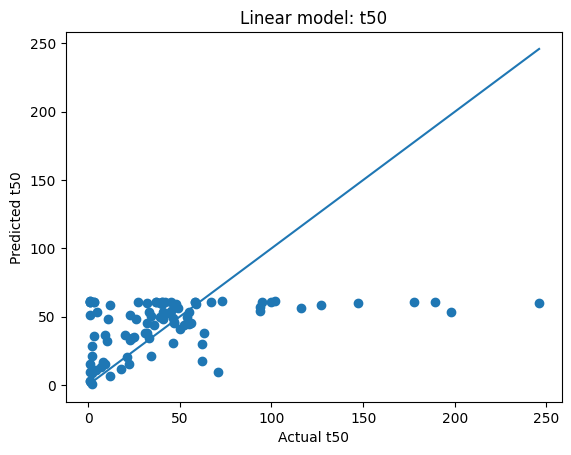

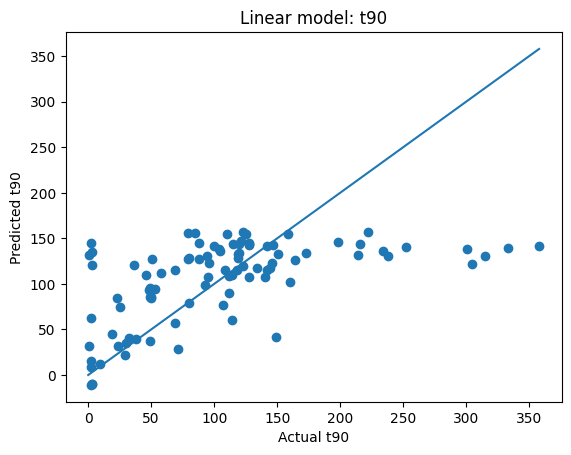

In [6]:
# t50
plt.figure()
plt.scatter(recovery_df['t50'], recovery_df['t50_pred'])
plt.xlabel("Actual t50")
plt.ylabel("Predicted t50")
plt.title("Linear model: t50")
plt.plot([0, max(y50)], [0, max(y50)])  # diagonal
plt.show()

# t90
plt.figure()
plt.scatter(recovery_df['t90'], recovery_df['t90_pred'])
plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("Linear model: t90")
plt.plot([0, max(y90)], [0, max(y90)])
plt.show()

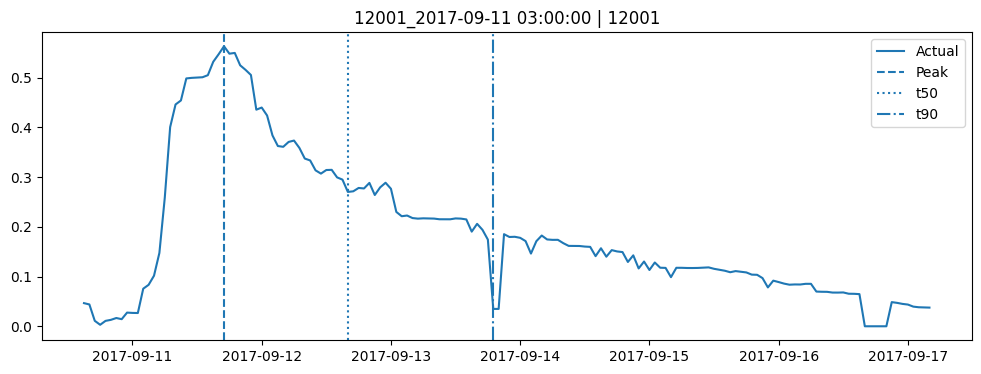

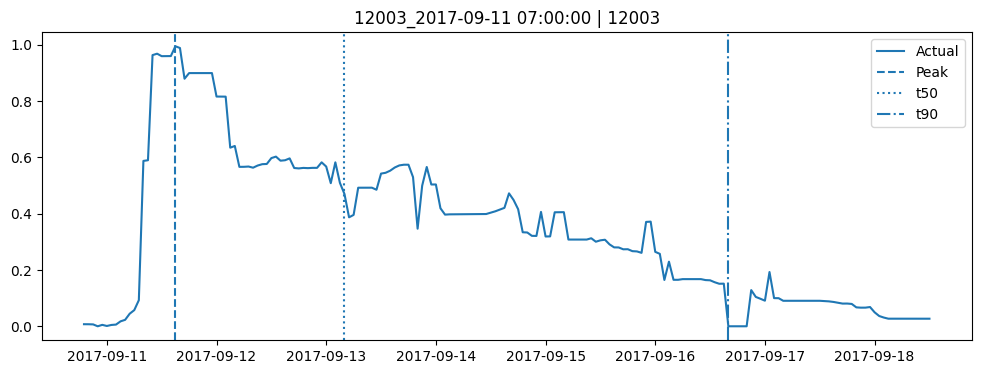

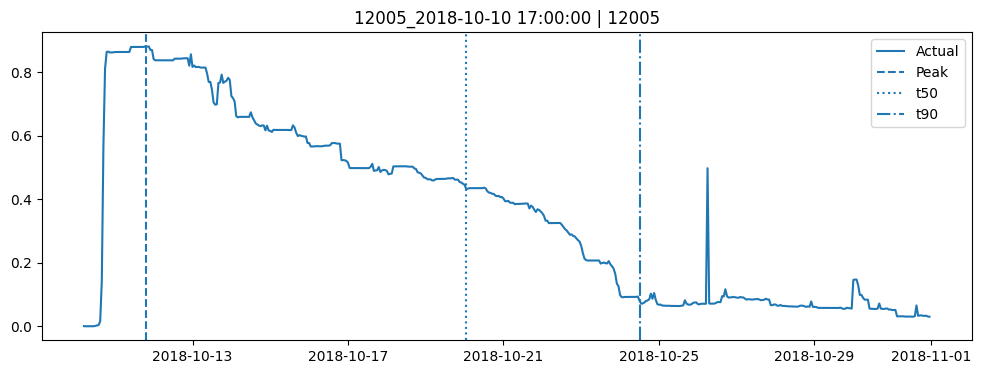

In [7]:
def plot_series_with_recovery(event_id, county):
    series = df[(df['event_id']==event_id) & (df['CountyFIPS']==county)].copy()
    series = series.sort_values('datetime')

    row = recovery_df[
        (recovery_df['event_id']==event_id) &
        (recovery_df['CountyFIPS']==county)
    ]

    if row.empty:
        return

    t50 = row['t50'].values[0]
    t90 = row['t90'].values[0]

    peak_idx = series['outageFraction'].idxmax()
    peak_time = series.loc[peak_idx, 'datetime']

    plt.figure(figsize=(12,4))
    plt.plot(series['datetime'], series['outageFraction'], label='Actual')

    # mark peak
    plt.axvline(peak_time, linestyle='--', label='Peak')

    # mark t50, t90
    plt.axvline(peak_time + pd.Timedelta(hours=t50), linestyle=':', label='t50')
    plt.axvline(peak_time + pd.Timedelta(hours=t90), linestyle='-.', label='t90')

    plt.title(f"{event_id} | {county}")
    plt.legend()
    plt.show()


# Example: first 3 windows
for _, row in recovery_df.head(3).iterrows():
    plot_series_with_recovery(row['event_id'], row['CountyFIPS'])

^ the above is not very useful as it stands, but it's helpful in highlighting the need for 

In [8]:
2+2

4